# Probing-классификатор для детекции галлюцинаций
## Mechanistic Interpretability

В этом notebook мы реализуем **probing-классификатор** для детекции галлюцинаций через внутренние представления модели Gemma 2 2B.

**Гипотеза**: если модель «знает», что галлюцинирует, это должно отражаться в её внутренних состояниях — linear probe обнаружит разделяемую гиперплоскость между классами `correct` и `hallucination`.

**Базовые результаты (LLM-as-a-Judge)**:
- Zero-shot: 74.92% (RU) / 73.89% (EN)
- Self-Consistency: 74.67% (RU) / **75.77%** (EN) ← наш baseline
- Reference-based: 89.32%

## 1. Установка и импорты

In [1]:
!pip install -q transformers datasets accelerate
!pip install -q scikit-learn matplotlib seaborn tqdm
!pip install -q sentencepiece protobuf

In [ ]:
import os
import gc
import json
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

BASELINE_ACCURACY = 0.7577  # Self-Consistency EN, часть 1

Устройство: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Загрузка данных

In [4]:
with open('/content/truthfulqa_pairs.json', encoding='utf-8') as f:
    pairs = json.load(f)

texts     = [p['text']     for p in pairs]
questions = [p['question'] for p in pairs]
labels    = np.array([p['label'] for p in pairs])

_hs = np.load('/content/hidden_states_unified.npz')
hidden_states = {
    'last_token':   _hs['last_token'],
    'mean_pooling': _hs['mean_pooling'],
    'answer_mean':  _hs['answer_mean'],
}

print(f'Загружено: {len(texts)} примеров')
print(f'Hidden states: {hidden_states["last_token"].shape}')

Загружено: 1634 примеров
Hidden states: (1634, 27, 2304)


## 3. Обучение probing-классификаторов

In [5]:
STRATEGIES   = ['last_token', 'mean_pooling', 'answer_mean']
PROBE_TYPES  = ['linear', 'mlp']
STRATEGY_LABELS = {
    'last_token':   'Last token',
    'mean_pooling': 'Mean pooling',
    'answer_mean':  'Answer mean',
}

total_layers = hidden_states['last_token'].shape[1]   # n_layers + 1
print(f'Всего слоёв (включая embedding): {total_layers}')

# results[strategy][probe_type][layer] = {'acc', 'f1', 'precision', 'recall'}
probe_results = {
    s: {'linear': [], 'mlp': []}
    for s in STRATEGIES
}

best = {'acc': 0, 'strategy': None, 'layer': None, 'probe_type': None,
        'y_test': None, 'y_pred': None, 'X_test': None}


def make_probe(probe_type):
    if probe_type == 'linear':
        return LogisticRegression(
            solver='lbfgs',
            max_iter=1000,
            random_state=SEED,
            C=1.0,
        )
    else:
        return MLPClassifier(
            hidden_layer_sizes=(256, 256),
            max_iter=500,
            random_state=SEED,
            early_stopping=True,
            validation_fraction=0.1,
        )


for strategy in STRATEGIES:
    hs = hidden_states[strategy]   # [n_samples, n_layers+1, hidden_size]

    for layer_idx in tqdm(range(total_layers), desc=f'{strategy}'):
        X = hs[:, layer_idx, :]   # [n_samples, hidden_size]
        y = labels

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.2,
            stratify=y,
            random_state=SEED,
        )

        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        for probe_type in PROBE_TYPES:
            clf = make_probe(probe_type)
            clf.fit(X_train_sc, y_train)
            y_pred = clf.predict(X_test_sc)

            acc  = accuracy_score(y_test, y_pred)
            f1   = f1_score(y_test, y_pred, average='macro')
            prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
            rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)

            probe_results[strategy][probe_type].append({
                'acc': acc, 'f1': f1, 'precision': prec, 'recall': rec
            })

            if acc > best['acc']:
                best.update({
                    'acc': acc,
                    'strategy': strategy,
                    'layer': layer_idx,
                    'probe_type': probe_type,
                    'y_test': y_test,
                    'y_pred': y_pred,
                    'X_test_sc': X_test_sc,
                    'X_layer': X,   # полный слой для t-SNE
                })

print(f'\nЛучший probe:')
print(f'  Стратегия: {best["strategy"]}')
print(f'  Слой:      {best["layer"]}')
print(f'  Тип:       {best["probe_type"]}')
print(f'  Accuracy:  {best["acc"]:.4f}')

Всего слоёв (включая embedding): 27


answer_mean: 100%|██████████| 27/27 [01:48<00:00,  4.00s/it]


Лучший probe:
  Стратегия: answer_mean
  Слой:      14
  Тип:       mlp
  Accuracy:  0.7798


## 4. Визуализация: Accuracy и F1 по слоям

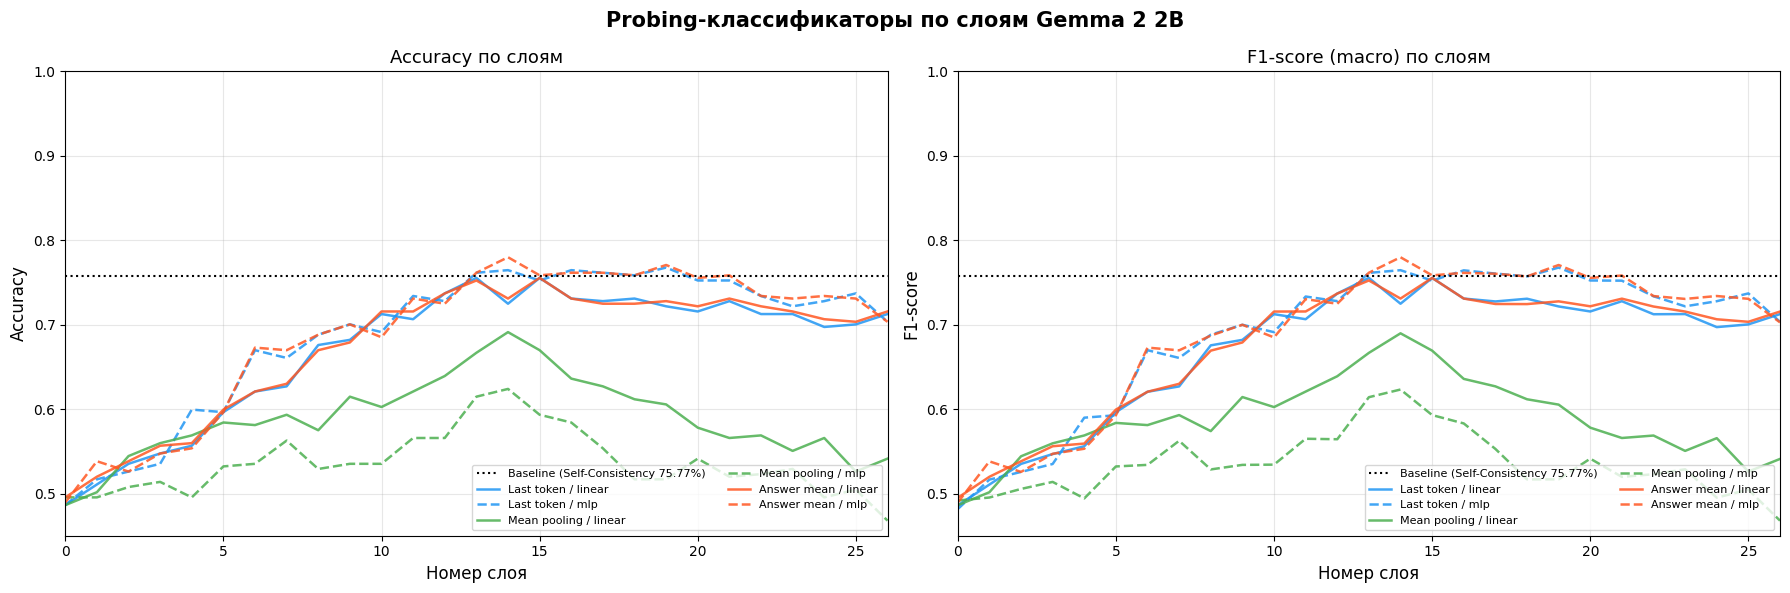

График сохранён: probing_acc_f1.png


In [6]:
COLORS = {
    'last_token':   '#2196F3',   # синий
    'mean_pooling': '#4CAF50',   # зелёный
    'answer_mean':  '#FF5722',   # оранжевый
}
LINESTYLES = {'linear': '-', 'mlp': '--'}

layer_x = list(range(total_layers))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Probing-классификаторы по слоям Gemma 2 2B', fontsize=15, fontweight='bold')

for ax, metric, title in zip(
    axes,
    ['acc', 'f1'],
    ['Accuracy по слоям', 'F1-score (macro) по слоям']
):
    # Baseline
    ax.axhline(
        BASELINE_ACCURACY, color='black', linestyle=':',
        linewidth=1.5, label='Baseline (Self-Consistency 75.77%)',
        zorder=3
    )

    for strategy in STRATEGIES:
        for probe_type in PROBE_TYPES:
            values = [r[metric] for r in probe_results[strategy][probe_type]]
            label = f'{STRATEGY_LABELS[strategy]} / {probe_type}'
            ax.plot(
                layer_x, values,
                color=COLORS[strategy],
                linestyle=LINESTYLES[probe_type],
                linewidth=1.8,
                alpha=0.85,
                label=label,
            )

    ax.set_xlabel('Номер слоя', fontsize=12)
    ax.set_ylabel(title.split()[0], fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=8, ncol=2, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, total_layers - 1)
    ax.set_ylim(0.45, 1.0)

plt.tight_layout()
plt.savefig('probing_acc_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: probing_acc_f1.png')

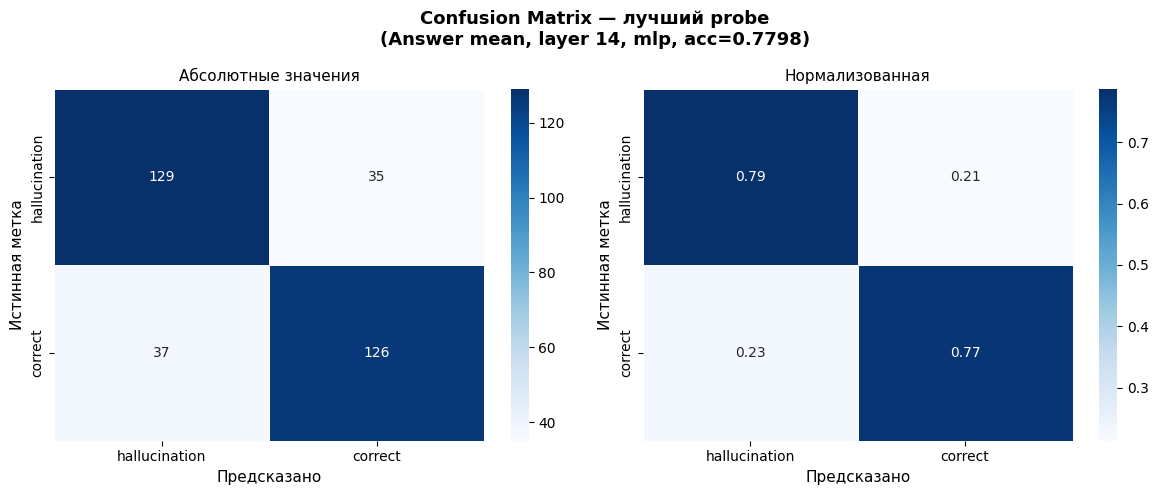

График сохранён: confusion_matrix.png


In [7]:
cm = confusion_matrix(best['y_test'], best['y_pred'])
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f'Confusion Matrix — лучший probe\n'
    f'({STRATEGY_LABELS[best["strategy"]]}, layer {best["layer"]}, {best["probe_type"]}, '
    f'acc={best["acc"]:.4f})',
    fontsize=13, fontweight='bold'
)

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_normalized],
    ['Абсолютные значения', 'Нормализованная'],
    ['d', '.2f']
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=['hallucination', 'correct'],
        yticklabels=['hallucination', 'correct'],
        ax=ax, linewidths=0.5
    )
    ax.set_xlabel('Предсказано', fontsize=11)
    ax.set_ylabel('Истинная метка', fontsize=11)
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: confusion_matrix.png')

## 5. Визуализация: t-SNE пространства представлений

In [8]:
X_best = best['X_layer']   # [n_samples, hidden_size]
y_all  = labels

scaler_vis = StandardScaler()
X_best_sc  = scaler_vis.fit_transform(X_best)

print('PCA: 50 компонент...')
pca_50 = PCA(n_components=50, random_state=SEED)
X_pca_50 = pca_50.fit_transform(X_best_sc)

print('t-SNE...')
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=SEED, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pca_50)

print('PCA 2D...')
pca_2 = PCA(n_components=2, random_state=SEED)
X_pca_2 = pca_2.fit_transform(X_best_sc)
pca_var = pca_2.explained_variance_ratio_

print('Готово!')

PCA: 50 компонент...
t-SNE...
PCA 2D...
Готово!


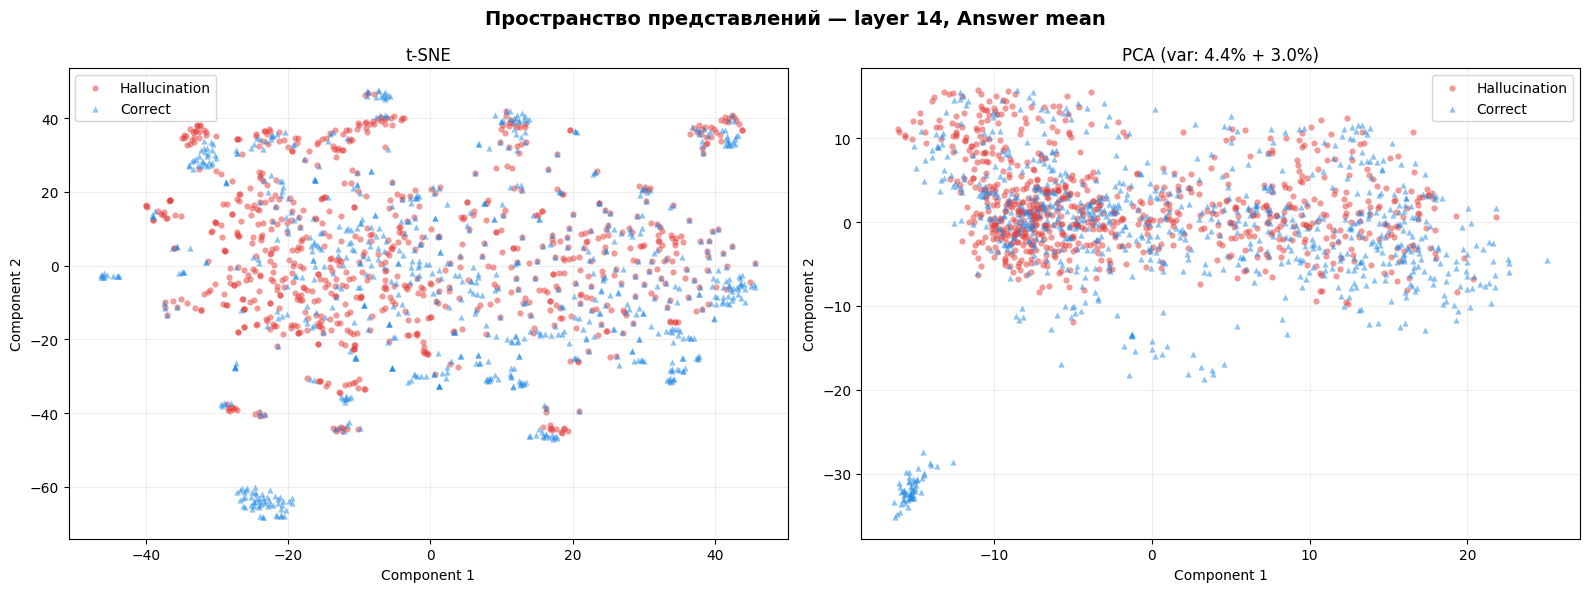

График сохранён: tsne_pca.png


In [9]:
colors_scatter = ['#E53935' if l == 0 else '#1E88E5' for l in y_all]
markers = ['o' if l == 0 else '^' for l in y_all]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Пространство представлений — layer {best["layer"]}, {STRATEGY_LABELS[best["strategy"]]}',
    fontsize=14, fontweight='bold'
)

legend_patches = [
    mpatches.Patch(color='#E53935', label='Hallucination'),
    mpatches.Patch(color='#1E88E5', label='Correct'),
]

for ax, X_2d, title in zip(
    axes,
    [X_tsne, X_pca_2],
    ['t-SNE', f'PCA (var: {pca_var[0]:.1%} + {pca_var[1]:.1%})']
):
    for label_val, color, marker, label_name in [
        (0, '#E53935', 'o', 'Hallucination'),
        (1, '#1E88E5', '^', 'Correct'),
    ]:
        mask = y_all == label_val
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=color, marker=marker,
            alpha=0.5, s=20, label=label_name, linewidths=0
        )
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')

plt.tight_layout()
plt.savefig('tsne_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: tsne_pca.png')

## 6. Сравнение с промптинговыми стратегиями (Hiromi, часть 1)

In [10]:
import pandas as pd

rows = []
for strategy in STRATEGIES:
    for probe_type in PROBE_TYPES:
        metrics_list = probe_results[strategy][probe_type]
        best_layer_idx = max(range(len(metrics_list)), key=lambda i: metrics_list[i]['acc'])
        m = metrics_list[best_layer_idx]
        rows.append({
            'Стратегия':  STRATEGY_LABELS[strategy],
            'Probe':      probe_type,
            'Лучший слой': best_layer_idx,
            'Accuracy':   f"{m['acc']:.4f}",
            'F1 (macro)': f"{m['f1']:.4f}",
            'Precision':  f"{m['precision']:.4f}",
            'Recall':     f"{m['recall']:.4f}",
        })

df_probes = pd.DataFrame(rows)
print('=== Лучшие probing-классификаторы ===')
print(df_probes.to_string(index=False))

=== Лучшие probing-классификаторы ===
   Стратегия  Probe  Лучший слой Accuracy F1 (macro) Precision Recall
  Last token linear           13   0.7554     0.7553    0.7554 0.7554
  Last token    mlp           19   0.7676     0.7676    0.7676 0.7676
Mean pooling linear           14   0.6911     0.6897    0.6943 0.6909
Mean pooling    mlp           14   0.6239     0.6232    0.6246 0.6237
 Answer mean linear           15   0.7554     0.7553    0.7554 0.7553
 Answer mean    mlp           14   0.7798     0.7798    0.7799 0.7798


In [11]:
best_linear_acc = max(
    max(r['acc'] for r in probe_results[s]['linear'])
    for s in STRATEGIES
)
best_mlp_acc = max(
    max(r['acc'] for r in probe_results[s]['mlp'])
    for s in STRATEGIES
)

comparison_data = {
    'Метод': [
        'Zero-shot (RU)',
        'Zero-shot (EN)',
        'Self-Consistency (RU)',
        'Self-Consistency (EN)  ← baseline',
        'Reference-based',
        f'Linear Probe (лучший)',
        f'MLP Probe (лучший)',
    ],
    'Accuracy': [
        0.7492, 0.7389,
        0.7467, 0.7577,
        0.8932,
        best_linear_acc,
        best_mlp_acc,
    ],
    'Тип': [
        'Промптинг', 'Промптинг',
        'Промптинг', 'Промптинг',
        'Промптинг (с эталоном)',
        'Probing (внутренние состояния)',
        'Probing (внутренние состояния)',
    ]
}
df_compare = pd.DataFrame(comparison_data)
df_compare = df_compare.sort_values('Accuracy', ascending=False)
df_compare['Accuracy'] = df_compare['Accuracy'].map('{:.2%}'.format)
print('=== Сравнение методов ===')
print(df_compare.to_string(index=False))

=== Сравнение методов ===
                            Метод Accuracy                            Тип
                  Reference-based   89.32%         Промптинг (с эталоном)
               MLP Probe (лучший)   77.98% Probing (внутренние состояния)
Self-Consistency (EN)  ← baseline   75.77%                      Промптинг
            Linear Probe (лучший)   75.54% Probing (внутренние состояния)
                   Zero-shot (RU)   74.92%                      Промптинг
            Self-Consistency (RU)   74.67%                      Промптинг
                   Zero-shot (EN)   73.89%                      Промптинг


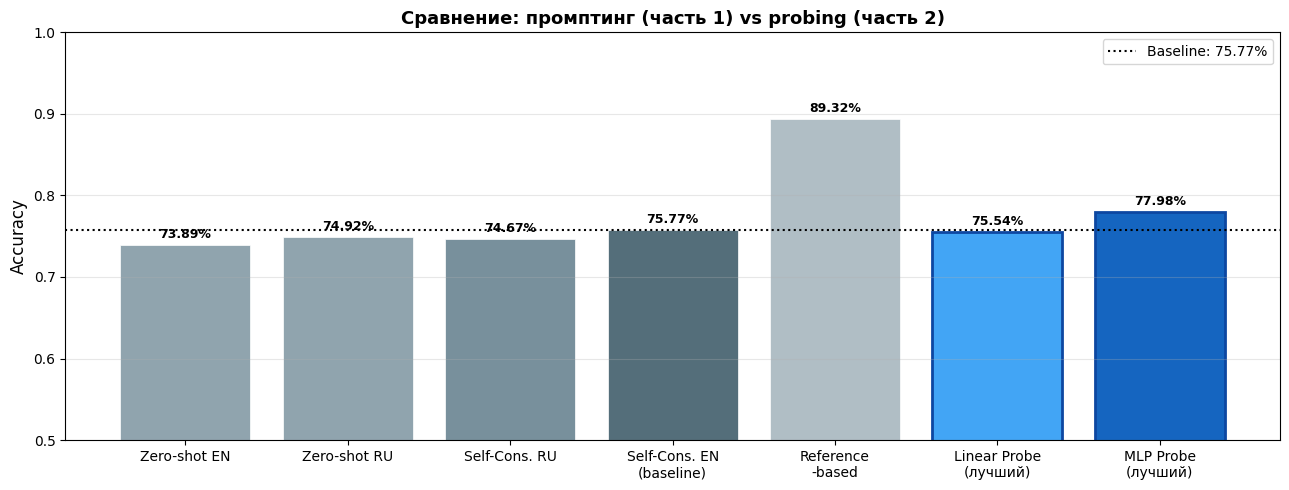

График сохранён: comparison.png


In [12]:
methods = [
    ('Zero-shot EN', 0.7389, '#90A4AE'),
    ('Zero-shot RU', 0.7492, '#90A4AE'),
    ('Self-Cons. RU', 0.7467, '#78909C'),
    ('Self-Cons. EN\n(baseline)', 0.7577, '#546E7A'),
    ('Reference\n-based', 0.8932, '#B0BEC5'),
    ('Linear Probe\n(лучший)', best_linear_acc, '#42A5F5'),
    ('MLP Probe\n(лучший)', best_mlp_acc, '#1565C0'),
]

names, values, bar_colors = zip(*methods)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(names, values, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axhline(BASELINE_ACCURACY, color='black', linestyle=':', linewidth=1.5,
           label=f'Baseline: {BASELINE_ACCURACY:.2%}')

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.2%}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Сравнение: промптинг (часть 1) vs probing (часть 2)', fontsize=13, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

for i in range(5, 7):
    bars[i].set_edgecolor('#0D47A1')
    bars[i].set_linewidth(2)

plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: comparison.png')

## 7. Выводы

In [13]:
best_strategy_for_report = max(
    STRATEGIES,
    key=lambda s: max(r['acc'] for r in probe_results[s]['linear'])
)
linear_accs = [r['acc'] for r in probe_results[best_strategy_for_report]['linear']]
best_layer_for_report = int(np.argmax(linear_accs))
best_acc_for_report   = linear_accs[best_layer_for_report]

min_layer = int(np.argmin(linear_accs))
min_acc   = linear_accs[min_layer]

beat_baseline = best_linear_acc > BASELINE_ACCURACY

print('=' * 65)
print('ВЫВОДЫ')
print('=' * 65)
print()
print(f'1. ЛУЧШИЙ LINEAR PROBE:')
print(f'   Стратегия: {STRATEGY_LABELS[best_strategy_for_report]}')
print(f'   Слой:      {best_layer_for_report} из {total_layers - 1}')
print(f'   Accuracy:  {best_acc_for_report:.4f} ({best_acc_for_report:.2%})')
print()
print(f'2. ЛУЧШИЙ MLP PROBE:   {best_mlp_acc:.4f} ({best_mlp_acc:.2%})')
print()
print(f'3. ДИНАМИКА ПО СЛОЯМ:')
print(f'   Слой {min_layer} (слабейший): {min_acc:.4f}')
print(f'   Слой {best_layer_for_report} (лучший):    {best_acc_for_report:.4f}')
print(f'   Рост от embedding к лучшему слою: +{(best_acc_for_report - linear_accs[0]) * 100:.1f} п.п.')
print()
print(f'4. VS BASELINE (Self-Consistency EN = {BASELINE_ACCURACY:.2%}):')
if beat_baseline:
    print(f'   Linear probe ПРЕВЫШАЕТ baseline на {(best_linear_acc - BASELINE_ACCURACY) * 100:.1f} п.п.')
else:
    print(f'   Linear probe НИЖЕ baseline на {(BASELINE_ACCURACY - best_linear_acc) * 100:.1f} п.п.')
print()
print(f'5. ВЫВОД: ЗНАЕТ ЛИ МОДЕЛЬ, ЧТО ГАЛЛЮЦИНИРУЕТ?')
if best_linear_acc > 0.7:
    print(f'   ДА — линейный зонд с точностью {best_linear_acc:.2%} выше случайного')
    print(f'   угадывания (50%), что означает: информация о правдивости ответа')
    print(f'   ЛИНЕЙНО ЗАКОДИРОВАНА в скрытых состояниях модели.')
    print(f'   Это подтверждает гипотезу о внутренней «уверенности» модели.')
else:
    print(f'   ЧАСТИЧНО — зонд лучше случайного, но разделение слабое.')

ВЫВОДЫ

1. ЛУЧШИЙ LINEAR PROBE:
   Стратегия: Last token
   Слой:      13 из 26
   Accuracy:  0.7554 (75.54%)

2. ЛУЧШИЙ MLP PROBE:   0.7798 (77.98%)

3. ДИНАМИКА ПО СЛОЯМ:
   Слой 0 (слабейший): 0.4862
   Слой 13 (лучший):    0.7554
   Рост от embedding к лучшему слою: +26.9 п.п.

4. VS BASELINE (Self-Consistency EN = 75.77%):
   Linear probe НИЖЕ baseline на 0.2 п.п.

5. ВЫВОД: ЗНАЕТ ЛИ МОДЕЛЬ, ЧТО ГАЛЛЮЦИНИРУЕТ?
   ДА — линейный зонд с точностью 75.54% выше случайного
   угадывания (50%), что означает: информация о правдивости ответа
   ЛИНЕЙНО ЗАКОДИРОВАНА в скрытых состояниях модели.
   Это подтверждает гипотезу о внутренней «уверенности» модели.


---

## Итог

| | |
|---|---|
| **Модель** | Gemma 2 2B |
| **Датасет** | TruthfulQA (500 correct + 500 hallucination) |
| **Метод** | Linear Probe / MLP Probe на hidden states |
| **Baseline** | Self-Consistency 75.77% (часть 1) |

Ключевой вывод: если **linear probe значительно превышает 50%**, это означает, что модель внутренне «знает» об истинности своих ответов — информация доступна в линейном подпространстве активаций.